In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [11]:
def generate_customer_data(n_customers=600, random_state=42):
    """Simulate an e-commerce customer purchase-behaviour dataset."""

    rng = np.random.default_rng(random_state)

    n_premium = n_customers // 3
    n_occasional = n_customers // 3
    n_budget = n_customers - n_premium - n_occasional

    premium = pd.DataFrame({
        "annual_spend": rng.normal(2200, 300, n_premium),
        "purchase_frequency": rng.normal(38, 6, n_premium),
        "avg_order_value": rng.normal(140, 20, n_premium),
        "discount_usage_pct": rng.normal(8, 4, n_premium),
        "return_rate_pct": rng.normal(3, 2, n_premium),
        "days_since_last_purchase": rng.normal(5, 3, n_premium)
    })

    occasional = pd.DataFrame({
        "annual_spend": rng.normal(700, 150, n_occasional),
        "purchase_frequency": rng.normal(12, 4, n_occasional),
        "avg_order_value": rng.normal(65, 15, n_occasional),
        "discount_usage_pct": rng.normal(25, 8, n_occasional),
        "return_rate_pct": rng.normal(6, 3, n_occasional),
        "days_since_last_purchase": rng.normal(20, 8, n_occasional)
    })

    budget = pd.DataFrame({
        "annual_spend": rng.normal(180, 60, n_budget),
        "purchase_frequency": rng.normal(5, 2, n_budget),
        "avg_order_value": rng.normal(25, 8, n_budget),
        "discount_usage_pct": rng.normal(55, 12, n_budget),
        "return_rate_pct": rng.normal(9, 4, n_budget),
        "days_since_last_purchase": rng.normal(45, 15, n_budget)
    })

    data = pd.concat([premium, occasional, budget], ignore_index=True)

    data["annual_spend"] = data["annual_spend"].clip(lower=20)
    data["purchase_frequency"] = data["purchase_frequency"].clip(lower=1)
    data["avg_order_value"] = data["avg_order_value"].clip(lower=5)
    data["discount_usage_pct"] = data["discount_usage_pct"].clip(0, 100)
    data["return_rate_pct"] = data["return_rate_pct"].clip(0, 100)
    data["days_since_last_purchase"] = data["days_since_last_purchase"].clip(lower=0)

    data.insert(
        0,
        "customer_id",
        [f"CUST{i:05d}" for i in range(1, len(data) + 1)]
    )

    return data.sample(frac=1, random_state=random_state).reset_index(drop=True)

In [12]:
def preprocess(data):

    feature_cols = [
        "annual_spend",
        "purchase_frequency",
        "avg_order_value",
        "discount_usage_pct",
        "return_rate_pct",
        "days_since_last_purchase"
    ]

    X = data[feature_cols].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, feature_cols, scaler

In [13]:
def elbow_method(X_scaled, k_range=range(1, 11)):

    inertias = []
    silhouette_scores = []

    for k in k_range:

        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=42
        )

        labels = km.fit_predict(X_scaled)

        inertias.append(km.inertia_)

        if k > 1:
            silhouette_scores.append(
                silhouette_score(X_scaled, labels)
            )
        else:
            silhouette_scores.append(np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(list(k_range), inertias, marker="o")
    axes[0].set_title("Elbow Method")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("WCSS")
    axes[0].grid(True)

    axes[1].plot(list(k_range), silhouette_scores, marker="o")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Score")
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("elbow_and_silhouette.png")
    plt.show()

    return inertias, silhouette_scores

In [14]:
def run_kmeans(X_scaled, n_clusters=3):

    km = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    return km, labels

In [15]:
def assign_segment_names(data, feature_cols, labels):

    data = data.copy()
    data["cluster"] = labels

    cluster_spend = (
        data.groupby("cluster")["annual_spend"]
        .mean()
        .sort_values(ascending=False)
    )

    ordered_clusters = cluster_spend.index.tolist()

    names = ["Premium", "Occasional", "Budget"]

    if len(ordered_clusters) != 3:
        names = [f"Segment {i+1}" for i in range(len(ordered_clusters))]

    mapping = {
        cluster_id: names[i]
        for i, cluster_id in enumerate(ordered_clusters)
    }

    data["segment"] = data["cluster"].map(mapping)

    return data, mapping

In [16]:
def visualize_pca(X_scaled, data, mapping):

    pca = PCA(n_components=2)

    components = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_

    plot_df = pd.DataFrame(
        components,
        columns=["PC1", "PC2"]
    )

    plot_df["segment"] = data["segment"].values

    colors = {
        "Premium": "#7c3aed",
        "Occasional": "#f59e0b",
        "Budget": "#0891b2"
    }

    plt.figure(figsize=(8, 6))

    for segment, group in plot_df.groupby("segment"):

        plt.scatter(
            group["PC1"],
            group["PC2"],
            label=segment,
            s=40,
            alpha=0.7,
            color=colors.get(segment),
            edgecolors="white",
            linewidths=0.5
        )

    plt.title("Customer Segments Visualised via PCA")
    plt.xlabel(
        f"Principal Component 1 ({explained[0]*100:.1f}% variance)"
    )
    plt.ylabel(
        f"Principal Component 2 ({explained[1]*100:.1f}% variance)"
    )

    plt.legend(title="Segment")
    plt.grid(True)
    plt.tight_layout()

    plt.savefig("pca_segments.png")
    plt.show()

    print(
        f"\nPCA Explained Variance:"
        f"\nPC1 = {explained[0]*100:.2f}%"
        f"\nPC2 = {explained[1]*100:.2f}%"
        f"\nTotal = {sum(explained)*100:.2f}%"
    )

    return pca, components

In [17]:
def profile_segments(data, feature_cols):

    profile = (
        data.groupby("segment")[feature_cols]
        .mean()
        .round(2)
    )

    profile["customer_count"] = (
        data.groupby("segment").size()
    )

    return profile

In [18]:
def recommend_discount_strategy(segment):

    strategies = {

        "Premium":
        "Loyalty rewards, exclusive offers, early product access, and small discounts (5–10%).",

        "Occasional":
        "Provide targeted discounts (15–25%), reminder emails, and personalized recommendations.",

        "Budget":
        "Offer flash sales, coupons, clearance deals, and discounts above 30%."

    }

    return strategies.get(
        segment,
        "Standard promotional offers."
    )

In [19]:
def main():

    print("=" * 70)
    print("E-COMMERCE CUSTOMER SEGMENTATION USING K-MEANS")
    print("=" * 70)

    # Generate Dataset
    data = generate_customer_data(n_customers=600)

    print(
        f"\nGenerated Dataset: "
        f"{data.shape[0]} Customers, "
        f"{data.shape[1]} Columns"
    )

    print(data.head())

    # Preprocessing
    X_scaled, feature_cols, scaler = preprocess(data)

    # Elbow Method
    print("\nRunning Elbow Method...\n")

    inertias, sil_scores = elbow_method(X_scaled)

    for k, (inertia, sil) in enumerate(
        zip(inertias, sil_scores),
        start=1
    ):

        sil_value = f"{sil:.3f}" if not np.isnan(sil) else "-"

        print(
            f"k = {k} | "
            f"Inertia = {inertia:.2f} | "
            f"Silhouette = {sil_value}"
        )

    print("\nSaved: elbow_and_silhouette.png")

    # KMeans
    optimal_k = 3

    km_model, labels = run_kmeans(
        X_scaled,
        n_clusters=optimal_k
    )

    # Assign Segment Names
    data, mapping = assign_segment_names(
        data,
        feature_cols,
        labels
    )

    print("\nCluster Mapping")
    print(mapping)

    # PCA
    pca, components = visualize_pca(
        X_scaled,
        data,
        mapping
    )

    print("\nSaved: pca_segments.png")

    # Segment Profile
    profile = profile_segments(
        data,
        feature_cols
    )

    print("\nSegment Profiles")
    print(profile)

    print("\nRecommended Discount Strategy")

    for segment in profile.index:

        print(
            f"\n[{segment}] "
            f"({int(profile.loc[segment,'customer_count'])} customers)"
        )

        print(
            recommend_discount_strategy(segment)
        )

    # Save CSV
    output_path = "segmented_customers.csv"

    data.to_csv(output_path, index=False)

    print(
        f"\nCustomer data saved as {output_path}"
    )

    print("\nPipeline Completed Successfully.")

E-COMMERCE CUSTOMER SEGMENTATION USING K-MEANS

Generated Dataset: 600 Customers, 7 Columns
  customer_id  annual_spend  purchase_frequency  avg_order_value  \
0   CUST00111   2330.327093           45.064471       108.780833   
1   CUST00420     40.374012            8.314752        31.745394   
2   CUST00566    123.507744            3.611913        12.200405   
3   CUST00078   2247.561907           31.325531       117.161235   
4   CUST00182   2265.814750           45.857304       116.873047   

   discount_usage_pct  return_rate_pct  days_since_last_purchase  
0            7.945413         1.496488                  9.462195  
1           30.463261        13.007336                 63.425916  
2           59.085285         3.872595                 70.148922  
3            9.680754         2.558065                 13.427633  
4            7.681082         0.000000                  7.564057  

Running Elbow Method...



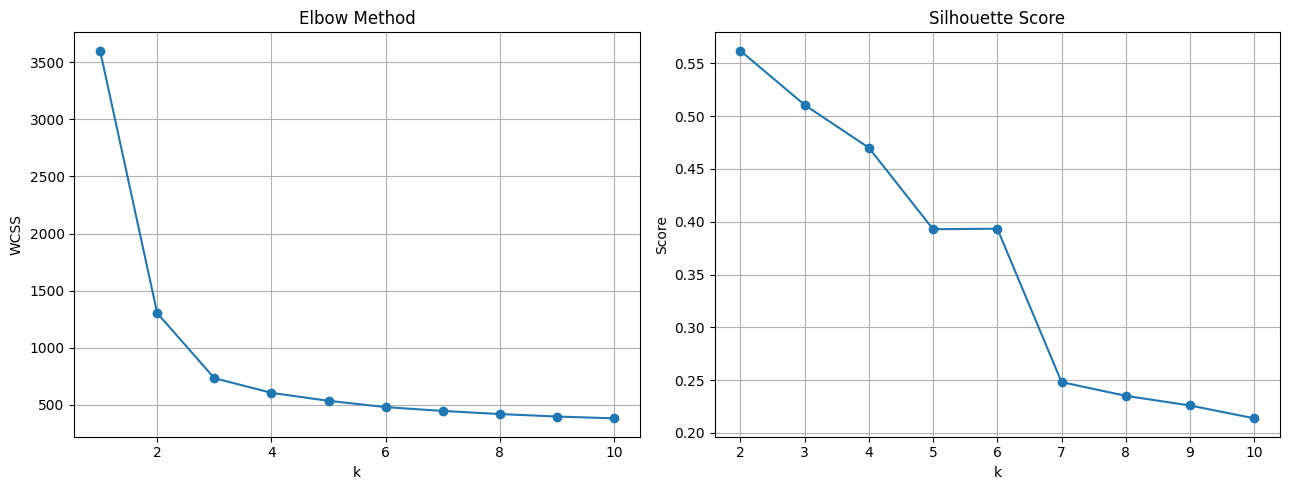

k = 1 | Inertia = 3600.00 | Silhouette = -
k = 2 | Inertia = 1303.85 | Silhouette = 0.562
k = 3 | Inertia = 734.32 | Silhouette = 0.511
k = 4 | Inertia = 605.98 | Silhouette = 0.470
k = 5 | Inertia = 535.94 | Silhouette = 0.393
k = 6 | Inertia = 481.12 | Silhouette = 0.393
k = 7 | Inertia = 447.51 | Silhouette = 0.248
k = 8 | Inertia = 420.32 | Silhouette = 0.235
k = 9 | Inertia = 398.55 | Silhouette = 0.226
k = 10 | Inertia = 382.75 | Silhouette = 0.214

Saved: elbow_and_silhouette.png

Cluster Mapping
{1: 'Premium', 0: 'Occasional', 2: 'Budget'}


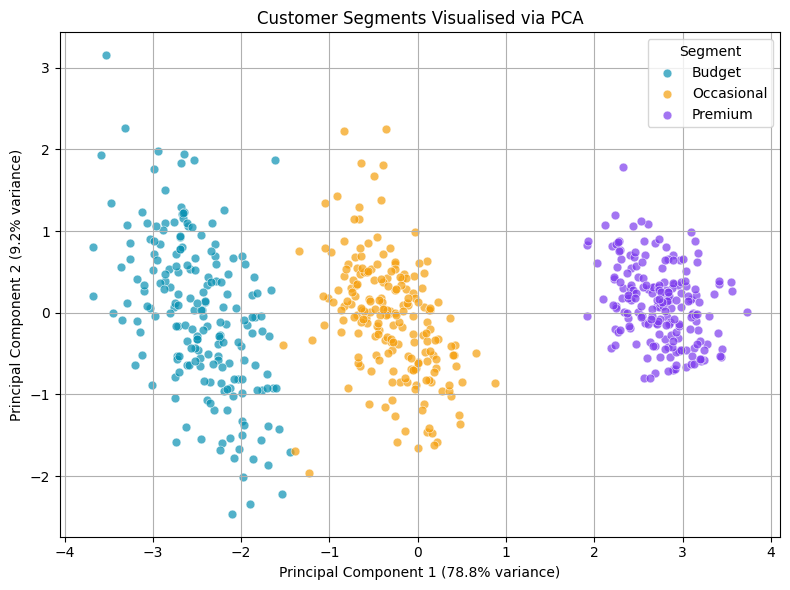


PCA Explained Variance:
PC1 = 78.84%
PC2 = 9.24%
Total = 88.08%

Saved: pca_segments.png

Segment Profiles
            annual_spend  purchase_frequency  avg_order_value  \
segment                                                         
Budget            186.35                4.97            25.60   
Occasional        684.19               11.55            62.79   
Premium          2190.86               38.12           138.64   

            discount_usage_pct  return_rate_pct  days_since_last_purchase  \
segment                                                                     
Budget                   55.64             8.88                     47.27   
Occasional               23.88             5.94                     20.42   
Premium                   7.89             3.03                      5.08   

            customer_count  
segment                     
Budget                 197  
Occasional             203  
Premium                200  

Recommended Discount Strategy

[Bu

In [20]:
if __name__ == "__main__":
    main()